In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import json
import cv2
from matplotlib.patches import Rectangle
import random

Dataset contents: ['data.yaml', 'README.dataset.txt', 'README.roboflow.txt', 'test', 'train', 'valid']
Class names: ['circle', 'pentagon', 'square', 'star', 'triangle']
Found 120 validation images


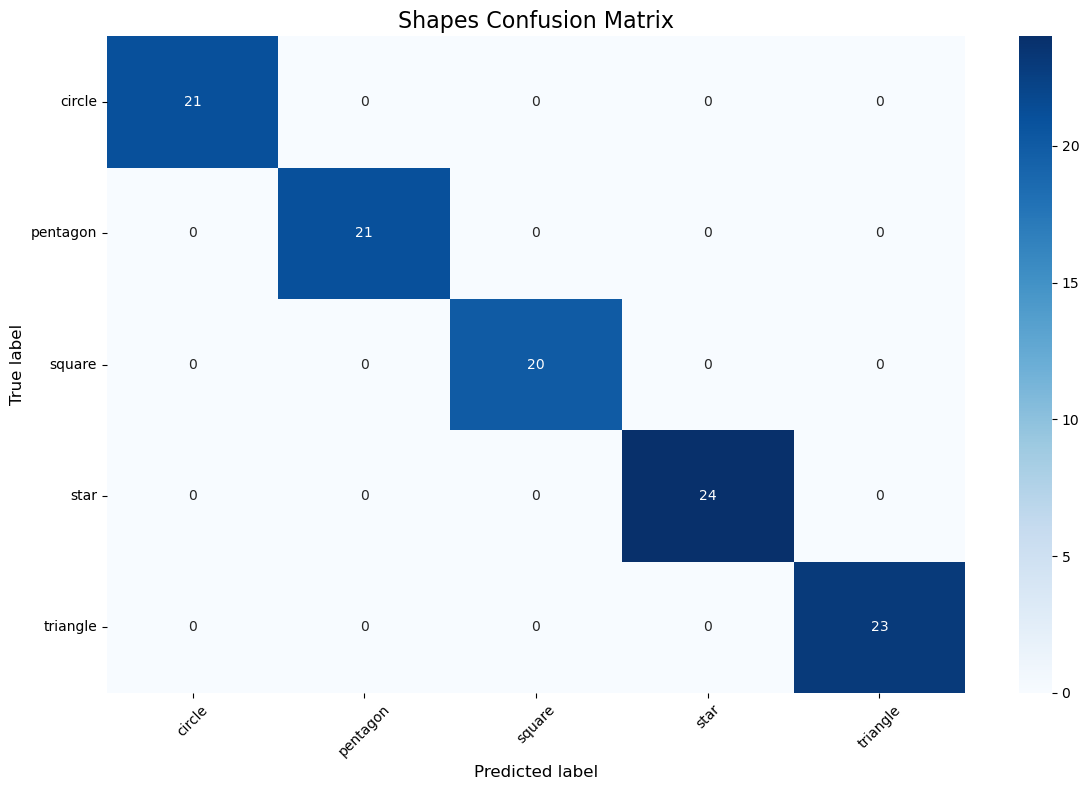

Classification Report:
              precision    recall  f1-score   support

      circle       1.00      1.00      1.00        21
    pentagon       1.00      1.00      1.00        21
      square       1.00      1.00      1.00        20
        star       1.00      1.00      1.00        24
    triangle       1.00      1.00      1.00        23

    accuracy                           1.00       109
   macro avg       1.00      1.00      1.00       109
weighted avg       1.00      1.00      1.00       109



In [11]:
# Set your dataset path
dataset_path = r"C:\Users\natal\Documents\2024-2025\Semester 2\Project One\2024-2025-projectone-ctai-RiddickNataliia\AI\Shape model\DAINO_v2.v4-shapes.yolov11"

# Verify the dataset structure
print("Dataset contents:", os.listdir(dataset_path))

# YOLO dataset typically has these folders:
# - images/ (train/valid/test)
# - labels/ (train/valid/test)
# - data.yaml (contains class names)

# First, let's find the data.yaml file to get class names
yaml_path = os.path.join(dataset_path, "data.yaml")
if not os.path.exists(yaml_path):
    raise FileNotFoundError(f"data.yaml not found at: {yaml_path}")

# Read class names from data.yaml
import yaml
with open(yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)
    
class_names = data_yaml['names']
print("Class names:", class_names)

# Path to validation set (adjust if you want to use train or test)
valid_images_path = os.path.join(dataset_path, "valid", "images")
valid_labels_path = os.path.join(dataset_path, "valid", "labels")

# Verify paths exist
if not os.path.exists(valid_images_path):
    raise FileNotFoundError(f"Validation images not found at: {valid_images_path}")
if not os.path.exists(valid_labels_path):
    raise FileNotFoundError(f"Validation labels not found at: {valid_labels_path}")

# Get list of validation images
image_files = [f for f in os.listdir(valid_images_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
print(f"Found {len(image_files)} validation images")

# Function to parse YOLO label file
def parse_yolo_label(label_path):
    with open(label_path, 'r') as f:
        lines = f.readlines()
    if not lines:
        return None
    # Return the first object's class (assuming one sign per image)
    return int(lines[0].split()[0])  # Class ID is the first number in the line

# Prepare true and predicted labels
true_labels = []
pred_labels = []

for img_file in image_files:
    # Get true label
    label_file = os.path.splitext(img_file)[0] + ".txt"
    label_path = os.path.join(valid_labels_path, label_file)
    
    if os.path.exists(label_path):
        true_class_id = parse_yolo_label(label_path)
        if true_class_id is not None:
            true_labels.append(class_names[true_class_id])
            
            # TEMPORARY: Replace this with your actual model prediction!
            # For now, we'll use the true label as prediction (perfect accuracy)
            pred_labels.append(class_names[true_class_id])
            
            # In reality, you would use:
            # img_path = os.path.join(valid_images_path, img_file)
            # prediction = your_model.predict(img_path)
            # pred_labels.append(class_names[predicted_class_id])

# Generate confusion matrix
cm = confusion_matrix(true_labels, pred_labels, labels=class_names)

# Visualization
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted label', fontsize=12)
plt.ylabel('True label', fontsize=12)
plt.title('Shapes Confusion Matrix', fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("shapes_confusion_matrix.png")
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(true_labels, pred_labels, target_names=class_names))
report = classification_report(true_labels, pred_labels, target_names=class_names, output_dict=True)
df = pd.DataFrame(report).transpose()
df.to_csv("classification_report.csv")

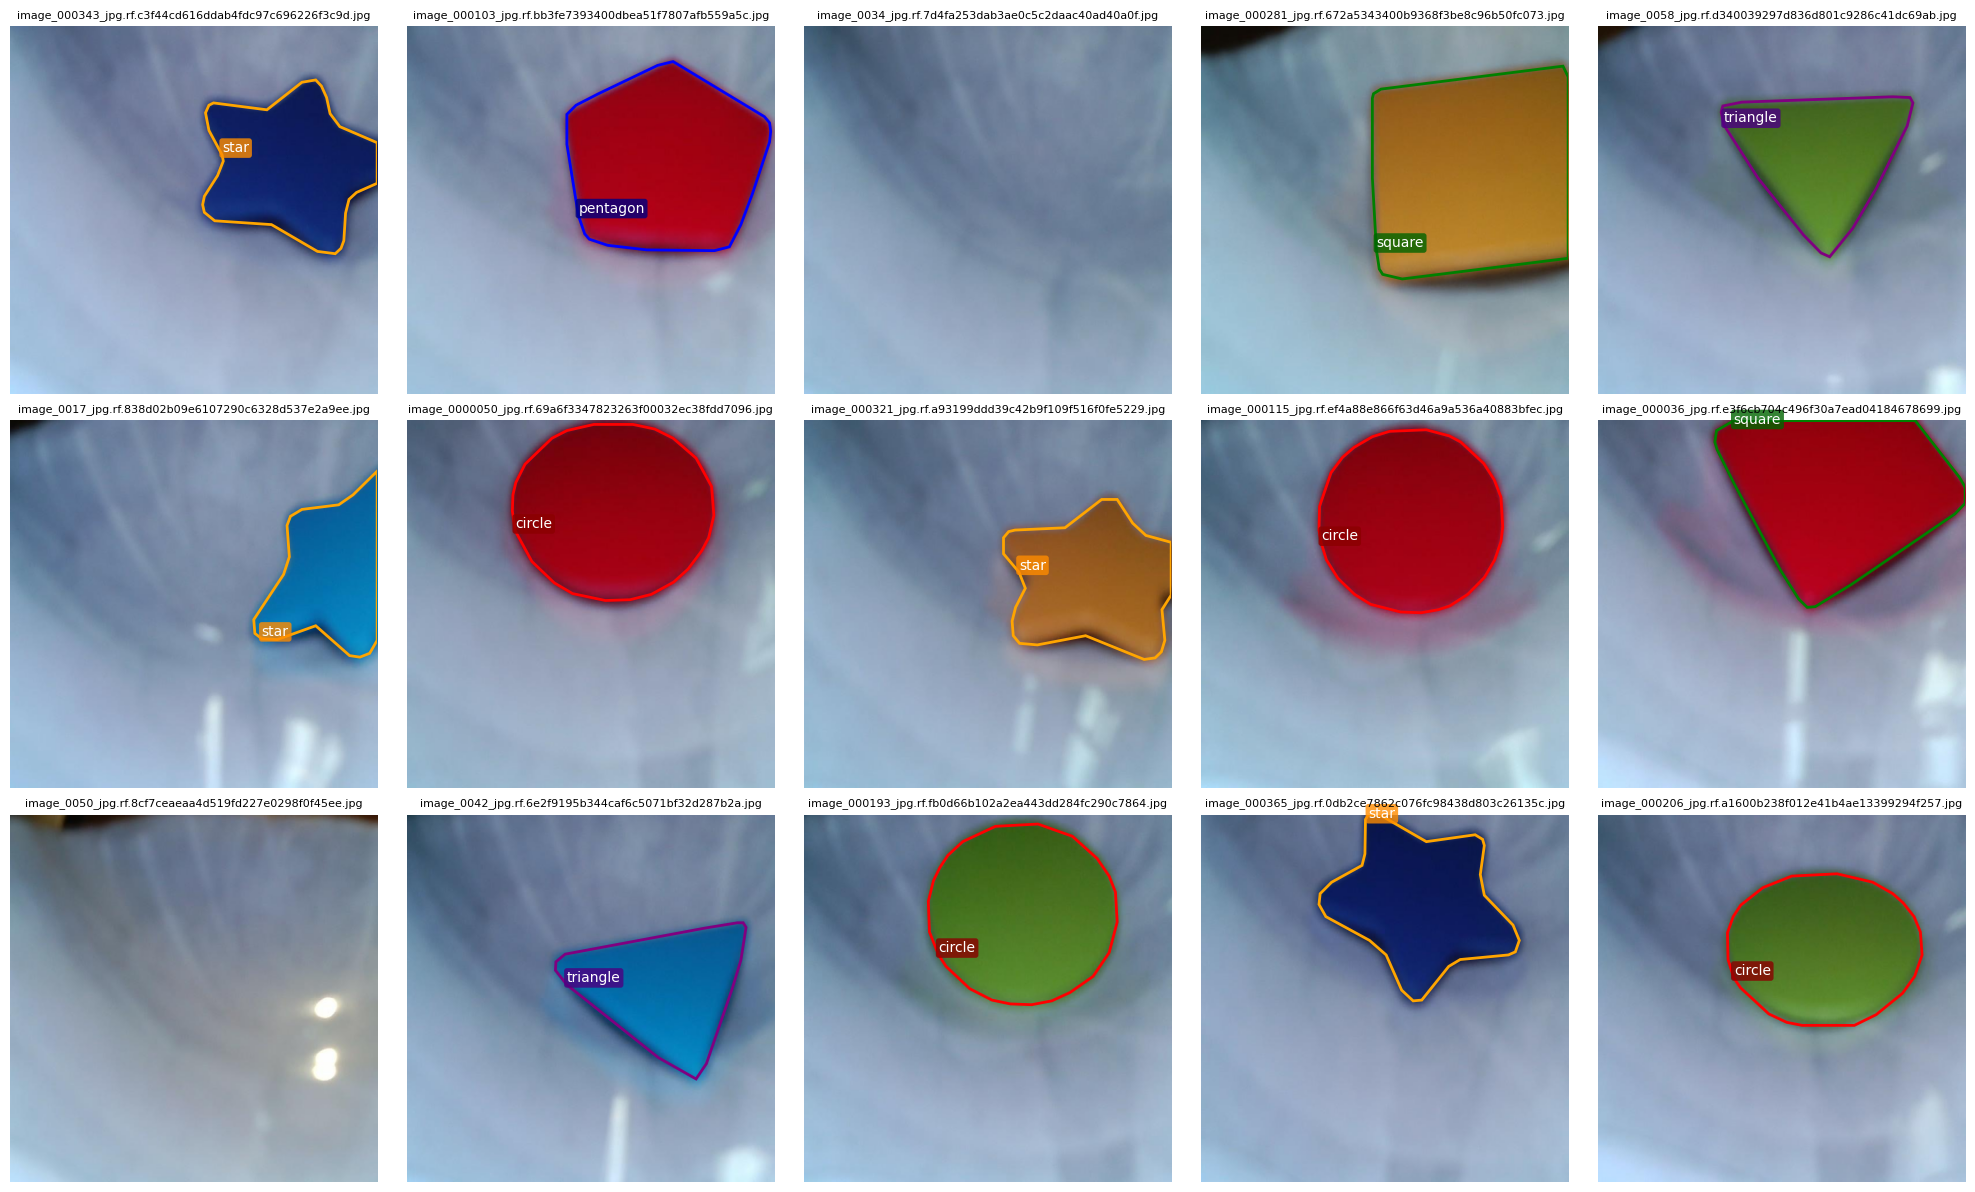

In [12]:
import os
import random
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import yaml

# === Paths ===
dataset_path = r"C:\Users\natal\Documents\2024-2025\Semester 2\Project One\2024-2025-projectone-ctai-RiddickNataliia\AI\Shape model\DAINO_v2.v4-shapes.yolov11"
img_dir = os.path.join(dataset_path, "valid", "images")
label_dir = os.path.join(dataset_path, "valid", "labels")

# === Load class names from data.yaml ===
yaml_path = os.path.join(dataset_path, "data.yaml")
with open(yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)
class_names = data_yaml['names']

# === Assign a unique color for each class ===
class_colors = {
    0: {'edgecolor': 'red',    'label_bg': 'darkred'},
    1: {'edgecolor': 'blue',   'label_bg': 'navy'},
    2: {'edgecolor': 'green',  'label_bg': 'darkgreen'},
    3: {'edgecolor': 'orange', 'label_bg': 'darkorange'},
    4: {'edgecolor': 'purple', 'label_bg': 'indigo'}
}

# === Load images ===
image_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
sample_images = random.sample(image_files, min(15, len(image_files)))

# === Plot images in 3x5 grid with YOLO segmentation masks ===
fig, axs = plt.subplots(3, 5, figsize=(20, 12))
axs = axs.flatten()

for ax, img_file in zip(axs, sample_images):
    img_path = os.path.join(img_dir, img_file)
    label_file = os.path.splitext(img_file)[0] + ".txt"
    label_path = os.path.join(label_dir, label_file)

    # Load image
    img = cv2.imread(img_path)
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    # Draw segmentation masks
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 9:
                    print(f"Skipping invalid line in {label_file}: {line}")
                    continue

                class_id = int(parts[0])
                class_name = class_names[class_id]
                points = list(map(float, parts[1:]))
                pixel_points = [(x * w, y * h) for x, y in zip(points[::2], points[1::2])]

                # Get color for this class
                colors = class_colors.get(class_id, {'edgecolor': 'yellow', 'label_bg': 'gold'})

                # Draw polygon outline only (transparent fill)
                poly = Polygon(
                    pixel_points,
                    closed=True,
                    linewidth=2,
                    edgecolor=colors['edgecolor'],
                    facecolor='none'
                )
                ax.add_patch(poly)

                # Add label
                if pixel_points:
                    ax.text(
                        pixel_points[0][0], max(pixel_points[0][1] - 5, 5),
                        class_name,
                        color='white',
                        fontsize=10,
                        bbox=dict(facecolor=colors['label_bg'], alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2')
                    )

    ax.imshow(img)
    ax.axis('off')
    ax.set_title(img_file, fontsize=8)

# Hide unused subplots
for i in range(len(sample_images), len(axs)):
    axs[i].axis('off')

plt.tight_layout()
plt.show()
